# PageRank via Power Iteration

A from-scratch implementation of Google's PageRank algorithm.

PageRank models a "random surfer" who follows links between pages, 
occasionally jumping to a random page instead. The long-run 
distribution of time spent on each page is given by the dominant 
eigenvector of a damped link matrix - this script finds that 
eigenvector efficiently using power iteration rather than a full 
eigendecomposition, which scales far better for large systems.

In [1]:
import numpy as np
import numpy.linalg as la


def generate_internet(n_pages: int, seed: int | None = None) -> np.ndarray:
    """
    Generate a random column-stochastic link matrix representing
    a toy "internet" of n_pages websites.

    Each page links to a random subset of other pages, and the
    columns are normalised so each sums to 1 (a page distributes
    its "vote" equally among the pages it links to).

    Parameters
    ----------
    n_pages : int
        Number of pages in the toy internet.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    np.ndarray
        An (n_pages x n_pages) column-stochastic link matrix.
    """
    rng = np.random.default_rng(seed)
    link_matrix = np.zeros((n_pages, n_pages))

    for col in range(n_pages):
        # Each page links to a random number of other pages (at least one)
        n_links = rng.integers(1, n_pages)
        linked_pages = rng.choice(n_pages, size=n_links, replace=False)
        link_matrix[linked_pages, col] = 1 / n_links

    return link_matrix

## Power iteration function

In [2]:
def page_rank(link_matrix: np.ndarray, d: float = 0.85, tol: float = 0.01) -> np.ndarray:
    """
    Compute PageRank scores for a link matrix via damped power iteration.

    Parameters
    ----------
    link_matrix : np.ndarray
        Column-stochastic matrix where entry (i, j) is the probability
        of moving from page j to page i.
    d : float, default 0.85
        Damping factor — the probability of following a link rather
        than jumping to a uniformly random page. Damping guarantees
        convergence to a single, unique PageRank even when the link
        graph has loops or disconnected components.
    tol : float, default 0.01
        Convergence tolerance on the change between iterations.

    Returns
    -------
    np.ndarray
        PageRank scores for each page, summing to n_pages (i.e. on
        a scale where the average page scores 1).
    """
    n = link_matrix.shape[0]

    # Damped transition matrix: mostly follow links, occasionally teleport
    M = d * link_matrix + (1 - d) / n * np.ones((n, n))

    r = np.ones(n)  # start with an even distribution
    last_r = r
    r = M @ r
    iterations = 0

    while la.norm(r - last_r) > tol:
        last_r = r
        r = M @ r
        iterations += 1

    print(f"Converged after {iterations} iterations.")
    return r

## Demo: ranking a random 100-page internet

Converged after 4 iterations.


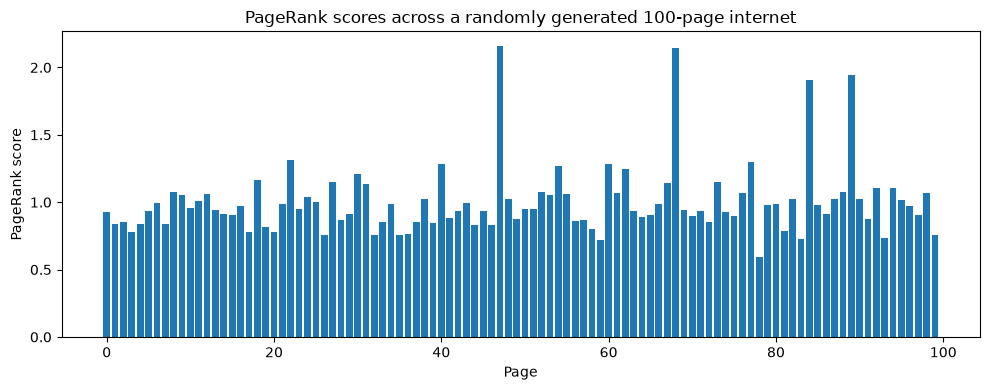

In [3]:
import matplotlib.pyplot as plt

# Build a toy internet and rank its pages
internet = generate_internet(100, seed=42)
scores = page_rank(internet, d=0.9)

plt.figure(figsize=(10, 4))
plt.bar(np.arange(scores.shape[0]), scores)
plt.xlabel("Page")
plt.ylabel("PageRank score")
plt.title("PageRank scores across a randomly generated 100-page internet")
plt.tight_layout()
plt.savefig("pagerank_demo.png", dpi=150)
plt.show()